In [1]:
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['axes.titley'] = 1.0    # y is in axes-relative coordinates.
plt.rcParams['axes.titlepad'] = -14  # pad is in points...
plt.rcParams['mathtext.rm'] = 'Arial'

cmap=plt.get_cmap('plasma')

In [2]:
from scipy.stats import linregress
from scipy.interpolate import interp1d
from scipy.optimize import minimize, curve_fit

def sigmoid(x, a, b, c, d):
    return a / (1. + np.exp(-c * (x - d))) + b

In [3]:
import gdown
#home_dir = '/content/drive/MyDrive/Cheng_project1_Marine_taxa_cell_cycle/Data/Culture_record_Accuri_data/2023_08_14_HTCC1062_Transfer_0727_13_Ammonia/'
home_dir = '/content/'

file_url = "https://drive.google.com/uc?id=1Dp7IQnW63PZh5r-dM12kC50NWb0P3g79"
output_path = "/content/ridge_line_data.json"
gdown.download(file_url, output_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Dp7IQnW63PZh5r-dM12kC50NWb0P3g79
To: /content/ridge_line_data.json
100%|██████████| 2.36M/2.36M [00:00<00:00, 25.0MB/s]


'/content/ridge_line_data.json'

In [4]:
import random

In [5]:
# @title Cell cycle parameters analysis

def get_chromosome_per_cell(X_range, ridge_line):
  return np.dot(ridge_line/np.transpose([ridge_line.sum(axis=1)]), X_range)

def get_cdf(histogram):
  cumsum = np.cumsum(histogram)
  cdf = cumsum/cumsum[-1]

  return cdf

def my_norm_pdf(x_fit, sigma, mu, y_max):
  y_fit = 1/(sigma*np.sqrt(2*np.pi))*np.exp(-0.5*((x_fit - mu)/sigma)**2)
  if np.max(y_fit)!=0:
    output_Y= y_fit/np.max(y_fit)*y_max
  else:
    output_Y = y_fit
  return output_Y

class LR_result:
  def __init__(self, y_fit, ci, pi, slope, intercept, slope_std, intercept_std):
    self.y_fit=y_fit
    self.ci=ci
    self.pi=pi
    self.slope=slope
    self.intercept=intercept
    self.slope_std=slope_std
    self.intercept_var=intercept_std

def linearfit(x, y, x_fit):
  """Linear fit of x and y with uncertainty and plots results."""
  x, y = np.asarray(x), np.asarray(y)
  n = y.size
  p, cov = np.polyfit(x, y, 1, cov=True)  # coefficients and covariance matrix

  perr = np.sqrt(np.diag(cov))     # standard-deviation estimates for each coefficient
  R2 = np.corrcoef(x, y)[0, 1]**2  # coefficient of determination between x and y
  resid = y - np.polyval(p, x)
  s_err = np.sqrt(np.sum(resid**2)/(n - 2))  # standard deviation of the error (residuals)

  # Confidence interval for the linear fit:
  t = stats.t.ppf(0.975, n - 2)
  ci = t * s_err * np.sqrt(    1/n + (x_fit - np.mean(x_fit))**2/np.sum((x_fit-np.mean(x_fit))**2))
  # Prediction interval for the linear fit:
  pi = t * s_err * np.sqrt(1 + 1/n + (x_fit - np.mean(x_fit))**2/np.sum((x_fit-np.mean(x_fit))**2))

  slope = p[0]
  intercept = p[1]
  slope_std = perr[0]
  intercept_std = perr[1]

  y_fit = np.polyval(p, x_fit)

  linear_fit_result = LR_result(y_fit, ci, pi, slope, intercept, slope_std, intercept_std)
  return linear_fit_result

#Ploidy level distributions analysis
def get_log_G(t, G0, tau, C):
  G = G0*(1
          +t*np.log(2)/(tau*(1-2**(-C/tau)))
          -(2**(t/tau)-1)/(2**(C/tau)-1)
          )

  G[t>=C] = G0*(1
              +C*np.log(2)/(tau*(1-2**(-C/tau)))
              -(2**(C/tau)-1)/(2**(C/tau)-1))

  return np.log(G)

#This function only works for bimodal distributions
def get_G1_S_G2(X_range, ridge_line):
  CF_RL_1 = curve_fit(my_norm_pdf, X_range[(X_range<=1.05) & (X_range>=0)], ridge_line[(X_range<=1.05) & (X_range>=0)])
  CF_RL_2 = curve_fit(my_norm_pdf, X_range[X_range>=1.95], ridge_line[X_range>=1.95])


  pdf_1 = my_norm_pdf(X_range, CF_RL_1[0][0], CF_RL_1[0][1],CF_RL_1[0][2])
  pdf_2 = my_norm_pdf(X_range, CF_RL_2[0][0], CF_RL_2[0][1],CF_RL_2[0][2])

  print(CF_RL_1, CF_RL_2)
  shoulder = ridge_line-pdf_1-pdf_2

  return pdf_1, pdf_2, shoulder

def get_genome_distribution(C, time_points, Forks, Genome_points):
  G_linspace=np.array([])
  n_G_A=np.array([])
  for Fi in range(len(Forks)):
    Fork=Forks[Fi]
    if Fork!=0:
      G_linspace_temp = np.arange(Genome_points[Fi]+0.001, Genome_points[Fi+1]-0.001, 0.001)
      #print(np.mean(np.diff(G_linspace_temp)))
      n_G_A_temp = np.log(2)*2**(1-
                                  (G_linspace_temp-Genome_points[Fi]+
                                    time_points[Fi]*Fork/C
                                  )/(Fork/C)
                                )/(Fork/C)

    else:
      G_linspace_temp=Genome_points[Fi]
      n_G_A_temp=(2**(1-time_points[Fi])-2**(1-time_points[Fi+1]))/0.001
    G_linspace=np.r_[G_linspace, G_linspace_temp]
    n_G_A=np.r_[n_G_A, n_G_A_temp]
  #print(np.min(np.diff(G_linspace)))
  return (G_linspace, n_G_A)

def get_replication_forks(C,D):
  C = abs(C)
  D = abs(D)
  #integral number of division cycles
  f_CD=np.floor(C+D).astype(int)
  f_D=np.floor(D).astype(int)
  c_CD=np.ceil(C+D).astype(int)
  c_D=np.ceil(D).astype(int)

  #Four targeted time points:
  #0
  #a_init
  #a_ter
  #1
  a_ter=c_D-D
  a_init=c_CD-(C+D)

  if a_init>a_ter:
    time_points=np.array([0, a_ter, a_init, 1])
    Forks=np.array([(2**f_CD-1)-(2**f_D-1), (2**f_CD-1)-(2**c_D-1), (2**c_CD-1)-(2**c_D-1)])
  else:
    time_points=np.array([0, a_init, a_ter, 1])
    Forks=np.array([(2**f_CD-1)-(2**f_D-1), (2**c_CD-1)-(2**f_D-1), (2**c_CD-1)-(2**c_D-1)])

  coeff_matrix=np.ones((4,3))+np.tril(np.ones((4,3)),-1)
  Genome_points=np.matmul(coeff_matrix,np.diff(time_points)*Forks/C)

  return time_points, Forks, Genome_points

def theoretical_DNA_distribution_CD(C, D):
  time_points, Forks, Genome_points=get_replication_forks(C,D)
  (G_linspace, n_G_A) = get_genome_distribution(C, time_points, Forks, Genome_points)
  return G_linspace, n_G_A

#def V_func(xi, u, xj):
#  return np.exp(-0.5*((xi-xj)/(u*xj))**2)/(np.sqrt(2*np.pi)*u*xj)
def V_func(xi, u, u0, xj):
  return np.exp(-0.5*((xi-xj)/(u*xj+u0))**2)/(np.sqrt(2*np.pi)*(u*xj+u0))

def experimental_genome_prediction_cv(x_list, C, D, u, u0):
#def experimental_genome_prediction_cv(x_list, C, D, u):
  #print(C,D)
  G_linspace, n_G_A = theoretical_DNA_distribution_CD(C, D)
  xi_list = np.arange(G_linspace[int(np.floor(len(G_linspace)/2))]-G_linspace[0],
                      G_linspace[int(np.floor(len(G_linspace)/2))]+G_linspace[1], 0.01)
  N_xi = np.array([np.sum(n_G_A*V_func(xi, u, u0, G_linspace))*0.01 for xi in xi_list])
  #N_xi = np.array([np.sum(n_G_A*V_func(xi, u, G_linspace))*0.01 for xi in xi_list])

  output_Y = np.zeros(len(x_list))

  for i in range(len(xi_list)):
    xi = xi_list[i]
    output_Y[abs(x_list-xi)<=0.01] = N_xi[i]

  if np.max(output_Y)!=0:
    output_Y = output_Y/np.max(output_Y)

  return output_Y

def abs_difference_objective(fitting_parameters, X_range, PDF_data):
  C=abs(fitting_parameters[0])
  D=abs(fitting_parameters[1])
  u=abs(fitting_parameters[2])
  u0=abs(fitting_parameters[3])

  PDF_predict = experimental_genome_prediction_cv(X_range,C,D,u,u0)
  return np.sum(abs(PDF_predict-PDF_data))

def CDF_prediction(X_range,C,D,u,u0):
#def CDF_prediction(X_range,C,D,u):
  output_Y = experimental_genome_prediction_cv(X_range,C,D,u,u0)
  #output_Y = experimental_genome_prediction_cv(X_range,C,D,u)

  CDF_predict = np.cumsum(output_Y)

  #if CDF_predict[-1]!=0:
  #  CDF_predict = CDF_predict/CDF_predict[-1]

  return CDF_predict

def KS_test_objective(fitting_parameters, X_range, CDF_data):
  C=abs(fitting_parameters[0])
  D=abs(fitting_parameters[1])
  u=abs(fitting_parameters[2])
  u0=abs(fitting_parameters[3])

  CDF_predict = CDF_prediction(X_range,C,D,u,u0)
  #CDF_predict = CDF_prediction(X_range,C,D,u)
  return np.max(abs(CDF_predict-CDF_data))

def run_optimization(X_range, ridge_line):
  #sel_bool = random.sample(range(len(X_range)), 1000)

  sel_bool = (X_range>=0.8)&(X_range<=2.2)
  ind = random.sample(range(sum(sel_bool)), 100)

  #RL_CDF = np.cumsum(ridge_line[sel_bool])
  #RL_CDF = RL_CDF/RL_CDF[-1]

  res0 = minimize(#KS_test_objective,
                  abs_difference_objective,
                  (0.40, 0.10, 0.05, 0.01),
                  #(0.5, 0.1, 0.06),
                  #args=(X_range[sel_bool], RL_CDF),
                  args = (X_range[sel_bool][ind], ridge_line[sel_bool][ind]),
                      method='L-BFGS-B',
                      bounds=((1e-3, 1), (1e-3, 1), (1e-3, 0.1), (0, 0.02)),
                      options = {'gtol':1e-10,
                                'disp': True,
                                'maxiter': 10000}
                      )

  print(res0.x)

  (C_0, D_0, u_0, u0_0) = res0.x
  #(C_0, D_0, u_0) = res0.x

  res1 = minimize(#KS_test_objective,
                  abs_difference_objective,
                (C_0, D_0, u_0, u0_0),
                  #(C_0, D_0, u_0),
                #args=(X_range[sel_bool], RL_CDF),
                args = (X_range[sel_bool][ind], ridge_line[sel_bool][ind]),
                method='Nelder-Mead',
                bounds=((C_0-C_0*0.1, C_0+C_0*0.1), (D_0-D_0*0.1, D_0+D_0*0.1), (1e-3, 0.1), (0, 0.02)),
                options={#'fatol':1e-10,
                          #'xatol':1e-10,
                          'disp':True,
                          #'maxiter':10000
                         }
                )

  print(res1.x)

  (C_0, D_0, u_0, u0_0) = res1.x
  #(C_0, D_0, u_0) = res1.x

  #res = minimize(abs_difference_objective,
  #               (C_0, D_0, u_0, u0_0),
  #               args=(X_range[sel_bool], ridge_line_1[0][sel_bool]),
  #               method='Nelder-Mead',
  #               options={'fatol':1e-10,
  #                        'xatol':1e-10,
  #                        'disp':True,
  #                        'maxiter':1000}
  #               )

  #print(res.x)

  CF_result = curve_fit(experimental_genome_prediction_cv, X_range[sel_bool][ind],
                        ridge_line[sel_bool][ind],
                        p0 = [C_0, D_0, u_0, u0_0],
                        #p0 = [0.5, 0.1, 0.06],
                        method='trf',
                        bounds=((0, 1)),
                        ftol = 1e-10, gtol=1e-10, verbose=2)

  prediction_1 = experimental_genome_prediction_cv(X_range , res1.x[0], res1.x[1], res1.x[2], res1.x[3])
  prediction_2 = experimental_genome_prediction_cv(X_range , CF_result[0][0], CF_result[0][1], CF_result[0][2], CF_result[0][3])
  #prediction_1 = experimental_genome_prediction_cv(X_range , res1.x[0], res1.x[1], res1.x[2])
  #prediction_2 = experimental_genome_prediction_cv(X_range , CF_result[0][0], CF_result[0][1], CF_result[0][2])

  #plt.plot(X_range, prediction_1)
  #plt.plot(X_range, prediction_2)
  #plt.plot(X_range, ridge_line,'k--')

  if sum(abs(prediction_1-ridge_line))>sum(abs(prediction_2-ridge_line)):
    [C,D,u,u0] = CF_result[0]
    #[C,D,u] = CF_result[0]
  else:
    (C,D,u,u0) = res1.x
    #(C,D,u) = res1.x

  return (abs(C),abs(D),abs(u),abs(u0))
  #return (abs(C), abs(D), abs(u))

In [6]:
import numpy as np
import json
import os

def save_notebook_data(filename, variable_patterns, max_index=8, globals_dict=None):
    """
    Save notebook variables matching specific patterns to a JSON file.

    Args:
        filename (str): The file path to save the data to
        variable_patterns (list): List of variable name patterns (e.g., 'X_range_{}')
        max_index (int): Maximum index to check for each pattern
        globals_dict (dict): Dictionary of global variables (defaults to current globals)
    """
    if globals_dict is None:
        # Get the globals from the calling context (the notebook)
        globals_dict = globals()

    data_to_save = {}

    # Collect all variables matching the patterns
    for pattern in variable_patterns:
        for i in range(1, max_index + 1):
            var_name = pattern.format(i)
            if var_name in globals_dict:
                value = globals_dict[var_name]
                # Convert numpy arrays to lists for JSON serialization
                if isinstance(value, np.ndarray):
                    data_to_save[var_name] = value.tolist()
                else:
                    data_to_save[var_name] = value

    # Create directory if it doesn't exist
    os.makedirs(os.path.dirname(os.path.abspath(filename)), exist_ok=True)

    # Save to JSON
    with open(filename, 'w') as f:
        json.dump(data_to_save, f)

    print(f"Saved {len(data_to_save)} variables to {filename}")
    return list(data_to_save.keys())

def load_notebook_data(filename, as_numpy=True, into_globals=True):
    """
    Load data from a JSON file into notebook variables.

    Args:
        filename (str): The file path to read the data from
        as_numpy (bool): Whether to convert lists to numpy arrays
        into_globals (bool): Whether to load variables directly into global namespace

    Returns:
        dict: The loaded data
    """
    with open(filename, 'r') as f:
        loaded_data = json.load(f)

    # Convert lists to numpy arrays if requested
    if as_numpy:
        for key, value in loaded_data.items():
            if isinstance(value, list):
                loaded_data[key] = np.array(value)

    # Add variables to global namespace if requested
    if into_globals:
        globals_dict = globals()
        for key, value in loaded_data.items():
            globals_dict[key] = value
        print(f"Loaded {len(loaded_data)} variables into global namespace")

    return loaded_data

# First, save all your data to a JSON file
# This cell should be run when you have all your data defined and want to save it

#variable_patterns = [
#    'X_range_{}',
#    'ridge_line_{}',
#    'ridge_line_{}_day',
#    'cell_count_{}'
#]

#saved_vars = save_notebook_data(home_dir+'ridge_line_data.json', variable_patterns)
#print(f"Saved variables: {saved_vars}")

# Later, in a new notebook session, load the data
# This will load all variables directly into your notebook's namespace

loaded_data = load_notebook_data(home_dir+'ridge_line_data.json')

Loaded 32 variables into global namespace


In [7]:
def interpolate_x_y(x,y):
  x = np.array(x)
  y = np.array(y)

  sort_bool = np.argsort(x)
  x = x[sort_bool]
  y = y[sort_bool]

  x_p = np.arange(np.round(np.min(x),2),np.round(np.max(x),2),0.01)
  y_p = np.interp(x_p,x,y)
  y_p = y_p/np.sum(y_p)

  y_cumsum = np.cumsum(y_p)

  return x_p, y_p, y_cumsum

def get_CH_index(x_p, y_p, y_cumsum, cutoff):
  lower_margin = x_p[np.abs(y_cumsum-cutoff)<0.02].max()
  upper_margin = x_p[np.abs(y_cumsum-(1-cutoff))<0.02].min()
  ch_index = upper_margin/lower_margin
  return lower_margin, upper_margin, ch_index

2.032608695652174
2.106382978723404
2.074468085106383
2.139784946236559
2.139784946236559
2.150537634408602
2.1170212765957444
2.1827956989247315
2.152173913043478
2.148936170212766
2.148936170212766
2.1827956989247315
2.0
1.9775280898876404
2.021052631578947
1.9680851063829787
2.0319148936170213
1.9787234042553192
2.032258064516129
2.0319148936170213
2.0425531914893615
2.0736842105263156
2.094736842105263
2.0729166666666665
2.082474226804124
2.082474226804124
2.020618556701031
2.0425531914893615
2.0
2.064516129032258
2.0103092783505154
1.8842105263157893
1.979166666666667
2.13
2.2500000000000004
2.3052631578947365
2.5164835164835164
2.032258064516129
2.0319148936170213
2.0425531914893615
2.0736842105263156
2.094736842105263
2.0729166666666665
2.082474226804124
2.082474226804124
2.020618556701031
2.0425531914893615
2.0
2.064516129032258
2.0103092783505154
1.8842105263157893
1.979166666666667
2.13
2.2500000000000004
2.3052631578947365


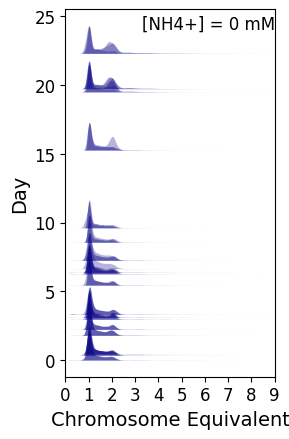

In [8]:
fig, axs = plt.subplots(figsize = (3,4.5))


for i in range(len(ridge_line_6_day)):
  y_base = ridge_line_6_day[i]
  gd = ridge_line_6[i]

  x_p, y_p, y_cumsum = interpolate_x_y(X_range_6, gd)
  lower_margin, upper_margin, ch_index = get_CH_index(x_p, y_p, y_cumsum, 0.1)

  print(ch_index)

  axs.fill_between(X_range_6, 2*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0),
                 linewidth=0, alpha=0.3)

for i in range(len(ridge_line_7_day)):
  y_base = ridge_line_7_day[i]
  gd = ridge_line_7[i]

  x_p, y_p, y_cumsum = interpolate_x_y(X_range_7, gd)
  lower_margin, upper_margin, ch_index = get_CH_index(x_p, y_p, y_cumsum, 0.1)

  print(ch_index)

  axs.fill_between(X_range_7, 2*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0),
                 linewidth=0, alpha=0.3)

for i in range(len(ridge_line_8_day)):
  y_base = ridge_line_8_day[i]
  gd = ridge_line_7[i]

  x_p, y_p, y_cumsum = interpolate_x_y(X_range_8, gd)
  lower_margin, upper_margin, ch_index = get_CH_index(x_p, y_p, y_cumsum, 0.1)

  print(ch_index)

  axs.fill_between(X_range_8, 2*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0),
                 linewidth=0, alpha=0.3)

axs.tick_params(labelsize=12)
axs.set_xlim(0,9)
axs.set_xticks([0,1,2,3,4,5,6,7,8,9])
axs.set_title('[NH4+] = 0 mM', loc='Right')
axs.set_xlabel('Chromosome Equivalent', fontsize=14)
axs.set_ylabel('Day', fontsize=14)


fig.tight_layout()

fig.savefig('/content/rlp_NH4_0.pdf')
fig.show()

2.032608695652174
2.106382978723404
2.074468085106383
2.139784946236559
2.139784946236559
2.150537634408602
2.1170212765957444
2.1827956989247315
2.152173913043478
2.148936170212766
2.148936170212766
2.1827956989247315
2.0
1.9775280898876404
2.021052631578947
1.9680851063829787
2.0319148936170213
1.9787234042553192
2.032258064516129
2.0319148936170213
2.0425531914893615
2.0736842105263156
2.094736842105263
2.0729166666666665
2.082474226804124
2.082474226804124
2.020618556701031
2.0425531914893615
2.0
2.064516129032258
2.0103092783505154
1.8842105263157893
1.979166666666667
2.13
2.2500000000000004
2.3052631578947365
2.5164835164835164
2.032258064516129
2.0319148936170213
2.0425531914893615
2.0736842105263156
2.094736842105263
2.0729166666666665
2.082474226804124
2.082474226804124
2.020618556701031
2.0425531914893615
2.0
2.064516129032258
2.0103092783505154
1.8842105263157893
1.979166666666667
2.13
2.2500000000000004
2.3052631578947365


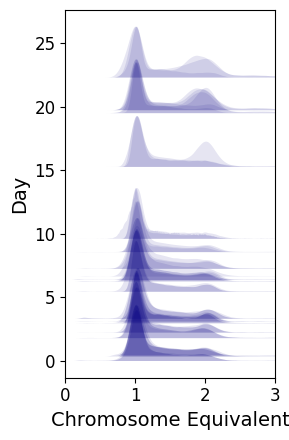

In [9]:
fig, axs = plt.subplots(figsize = (3,4.5))


for i in range(len(ridge_line_6_day)):
  y_base = ridge_line_6_day[i]
  gd = ridge_line_6[i]

  x_p, y_p, y_cumsum = interpolate_x_y(X_range_6, gd)
  lower_margin, upper_margin, ch_index = get_CH_index(x_p, y_p, y_cumsum, 0.1)

  print(ch_index)

  axs.fill_between(X_range_6, 4*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0),
                 linewidth=0, alpha=0.1)

for i in range(len(ridge_line_7_day)):
  y_base = ridge_line_7_day[i]
  gd = ridge_line_7[i]

  x_p, y_p, y_cumsum = interpolate_x_y(X_range_7, gd)
  lower_margin, upper_margin, ch_index = get_CH_index(x_p, y_p, y_cumsum, 0.1)

  print(ch_index)

  axs.fill_between(X_range_7, 4*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0),
                 linewidth=0, alpha=0.1)

for i in range(len(ridge_line_8_day)):
  y_base = ridge_line_8_day[i]
  gd = ridge_line_7[i]

  x_p, y_p, y_cumsum = interpolate_x_y(X_range_8, gd)
  lower_margin, upper_margin, ch_index = get_CH_index(x_p, y_p, y_cumsum, 0.1)

  print(ch_index)

  axs.fill_between(X_range_8, 4*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0),
                 linewidth=0, alpha=0.1)

axs.tick_params(labelsize=12)
axs.set_xlim(0,3)
axs.set_xticks([0,1,2,3])
#axs.set_title('[NH4+] = 0 mM', loc='Right')
axs.set_xlabel('Chromosome Equivalent', fontsize=14)
axs.set_ylabel('Day', fontsize=14)


fig.tight_layout()

fig.savefig('/content/rlp_NH4_0_presentation.pdf')
fig.show()

2.032258064516129
2.0869565217391304
2.086021505376344
2.1752577319587627
2.216494845360825
2.3367346938775513
2.4081632653061225
2.612244897959184
4.0
4.295238095238095
4.3619047619047615
4.915887850467289
5.559633027522936
6.240384615384615
4.66
2.947368421052632
2.916666666666667
2.5416666666666665


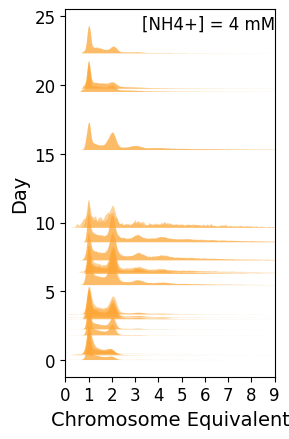

In [10]:
fig, axs = plt.subplots(figsize = (3,4.5))

for i in range(len(ridge_line_2_day)):
  y_base = ridge_line_2_day[i]
  gd = ridge_line_2[i]

  x_p, y_p, y_cumsum = interpolate_x_y(X_range_2, gd)
  lower_margin, upper_margin, ch_index = get_CH_index(x_p, y_p, y_cumsum, 0.1)

  print(ch_index)

  axs.fill_between(X_range_2, 2*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(4.0/5),
                 linewidth=0, alpha=0.5)

for i in range(len(ridge_line_3_day)):
  y_base = ridge_line_3_day[i]
  gd = ridge_line_3[i]
  axs.fill_between(X_range_3, 2*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(4.0/5),
                 linewidth=0, alpha=0.5)


axs.tick_params(labelsize=12)
axs.set_xlim(0,9)
axs.set_xticks([0,1,2,3,4,5,6,7,8,9])
axs.set_title('[NH4+] = 4 mM', loc='Right')
axs.set_xlabel('Chromosome Equivalent', fontsize=14)
axs.set_ylabel('Day', fontsize=14)


fig.tight_layout()

fig.savefig('/content/rlp_NH4_4.pdf')
fig.show()

In [11]:
def get_chromosome_per_cell(X_range, ridge_line):
  return np.dot(ridge_line/np.transpose([ridge_line.sum(axis=1)]), X_range)

def get_CHI(X_range, ridge_line):
  ch_index_list = []
  for i in range(len(ridge_line)):
    gd = ridge_line[i]
    x_p, y_p, y_cumsum = interpolate_x_y(X_range, gd)
    lower_margin, upper_margin, ch_index = get_CH_index(x_p, y_p, y_cumsum, 0.1)
    ch_index_list.append(ch_index)

  return ch_index_list

chromosome_per_cell_2 = get_chromosome_per_cell(X_range_2, ridge_line_2)
chromosome_per_cell_3 = get_chromosome_per_cell(X_range_3, ridge_line_3)

chromosome_per_cell_5 = get_chromosome_per_cell(X_range_5, ridge_line_5)

chromosome_per_cell_1 = get_chromosome_per_cell(X_range_1, ridge_line_1)
chromosome_per_cell_4 = get_chromosome_per_cell(X_range_4, ridge_line_4)

chromosome_per_cell_6 = get_chromosome_per_cell(X_range_6, ridge_line_6)
chromosome_per_cell_7 = get_chromosome_per_cell(X_range_7, ridge_line_7)
chromosome_per_cell_8 = get_chromosome_per_cell(X_range_8, ridge_line_8)

chi_2 = get_CHI(X_range_2, ridge_line_2)
chi_3 = get_CHI(X_range_3, ridge_line_3)

chi_5 = get_CHI(X_range_5, ridge_line_5)

chi_1 = get_CHI(X_range_1, ridge_line_1)
chi_4 = get_CHI(X_range_4, ridge_line_4)

chi_6 = get_CHI(X_range_6, ridge_line_6)
chi_7 = get_CHI(X_range_7, ridge_line_7)
chi_8 = get_CHI(X_range_8, ridge_line_8)

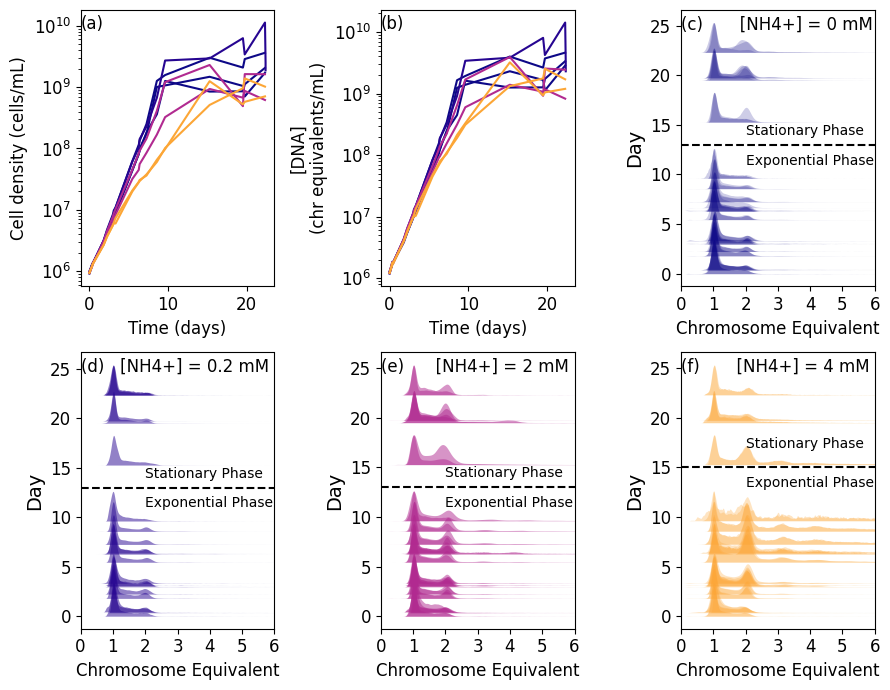

In [12]:
%matplotlib inline

fig, axs = plt.subplots(figsize = (9,7), ncols=3, nrows=2)
cmap=plt.get_cmap('plasma')
ax = axs[0][0]

ax.plot(ridge_line_6_day, cell_count_6, '-', color = cmap(0))
ax.plot(ridge_line_7_day, cell_count_7, '-', color = cmap(0))
ax.plot(ridge_line_8_day, cell_count_8, '-', color = cmap(0))

ax.plot(ridge_line_5_day, cell_count_5, '-', color = cmap(0.2/5))

ax.plot(ridge_line_1_day, cell_count_1, '-', color = cmap(2.0/5))
ax.plot(ridge_line_4_day, cell_count_4, '-', color = cmap(2.0/5))

ax.plot(ridge_line_2_day, cell_count_2, '-', color = cmap(4.0/5))
ax.plot(ridge_line_3_day, cell_count_3, '-', color = cmap(4.0/5))

ax.set_yscale('log', base=10)

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Cell density (cells/mL)', fontsize=12)
ax.tick_params(labelsize=12)
ax.set_title('(a)', loc='Left')

ax = axs[0][1]

ax.plot(ridge_line_6_day, cell_count_6*chromosome_per_cell_6, '-', color = cmap(0))
ax.plot(ridge_line_7_day, cell_count_7*chromosome_per_cell_7, '-', color = cmap(0))
ax.plot(ridge_line_8_day, cell_count_8*chromosome_per_cell_8, '-', color = cmap(0))

ax.plot(ridge_line_5_day, cell_count_5*chromosome_per_cell_5, '-', color = cmap(0.2/5))

ax.plot(ridge_line_1_day, cell_count_1*chromosome_per_cell_1, '-', color = cmap(2.0/5))
ax.plot(ridge_line_4_day, cell_count_4*chromosome_per_cell_4, '-', color = cmap(2.0/5))

ax.plot(ridge_line_2_day, cell_count_2*chromosome_per_cell_2, '-', color = cmap(4.0/5))
ax.plot(ridge_line_3_day, cell_count_3*chromosome_per_cell_3, '-', color = cmap(4.0/5))

ax.set_yscale('log', base=10)

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('[DNA]\n(chr equivalents/mL)', fontsize=12)
ax.tick_params(labelsize=12)
ax.set_title('(b)', loc='Left')

ax = axs[0][2]

for i in range(len(ridge_line_6_day)):
  y_base = ridge_line_6_day[i]
  gd = ridge_line_6[i]
  ax.fill_between(X_range_6, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0),
                 linewidth=0, alpha=0.2)

for i in range(len(ridge_line_7_day)):
  y_base = ridge_line_7_day[i]
  gd = ridge_line_7[i]
  ax.fill_between(X_range_7, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0),
                 linewidth=0, alpha=0.2)

for i in range(len(ridge_line_8_day)):
  y_base = ridge_line_8_day[i]
  gd = ridge_line_7[i]
  ax.fill_between(X_range_8, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0),
                 linewidth=0, alpha=0.2)

ax.plot([0,6],[13,13],'k--')
ax.text(2,14,'Stationary Phase')
ax.text(2,11,'Exponential Phase')

ax.tick_params(labelsize=12)
ax.set_xlim(0,6)
ax.set_xticks([0,1,2,3,4,5,6])
ax.set_title('(c)       [NH4+] = 0 mM', loc='Left')
ax.set_xlabel('Chromosome Equivalent', fontsize=12)
ax.set_ylabel('Day', fontsize=14)

ax = axs[1][0]

for i in range(len(ridge_line_5_day)):
  y_base = ridge_line_5_day[i]
  gd = ridge_line_5[i]
  ax.fill_between(X_range_5, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0.2/5),
                 linewidth=0, alpha=0.5)

ax.plot([0,6],[13,13],'k--')
ax.text(2,14,'Stationary Phase')
ax.text(2,11,'Exponential Phase')

ax.tick_params(labelsize=12)
ax.set_xlim(0,6)
ax.set_xticks([0,1,2,3,4,5,6])
ax.set_title('(d)   [NH4+] = 0.2 mM', loc='Left')
ax.set_xlabel('Chromosome Equivalent', fontsize=12)
ax.set_ylabel('Day', fontsize=14)

ax = axs[1][1]

for i in range(len(ridge_line_1_day)):
  y_base = ridge_line_1_day[i]
  gd = ridge_line_1[i]
  ax.fill_between(X_range_1, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(2.0/5),
                 linewidth=0, alpha=0.5)

for i in range(len(ridge_line_4_day)):
  y_base = ridge_line_4_day[i]
  gd = ridge_line_4[i]
  ax.fill_between(X_range_4, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(2.0/5),
                 linewidth=0, alpha=0.5)

ax.plot([0,6],[13,13],'k--')
ax.text(2,14,'Stationary Phase')
ax.text(2,11,'Exponential Phase')

ax.tick_params(labelsize=12)
ax.set_xlim(0,6)
ax.set_xticks([0,1,2,3,4,5,6])
ax.set_title('(e)      [NH4+] = 2 mM', loc='Left')
ax.set_xlabel('Chromosome Equivalent', fontsize=12)
ax.set_ylabel('Day', fontsize=14)

ax = axs[1][2]

for i in range(len(ridge_line_2_day)):
  y_base = ridge_line_2_day[i]
  gd = ridge_line_2[i]
  ax.fill_between(X_range_2, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(4.0/5),
                 linewidth=0, alpha=0.3)

for i in range(len(ridge_line_3_day)):
  y_base = ridge_line_3_day[i]
  gd = ridge_line_3[i]
  ax.fill_between(X_range_3, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(4.0/5),
                 linewidth=0, alpha=0.3)

ax.plot([0,6],[15,15],'k--')
ax.text(2,17,'Stationary Phase')
ax.text(2,13,'Exponential Phase')
ax.tick_params(labelsize=12)
ax.set_xlim(0,6)
ax.set_xticks([0,1,2,3,4,5,6])
ax.set_title('(f)       [NH4+] = 4 mM', loc='Left')
ax.set_xlabel('Chromosome Equivalent', fontsize=12)
ax.set_ylabel('Day', fontsize=14)

fig.tight_layout()

fig.savefig('/content/ridge_line_cell_count.pdf')
fig.show()

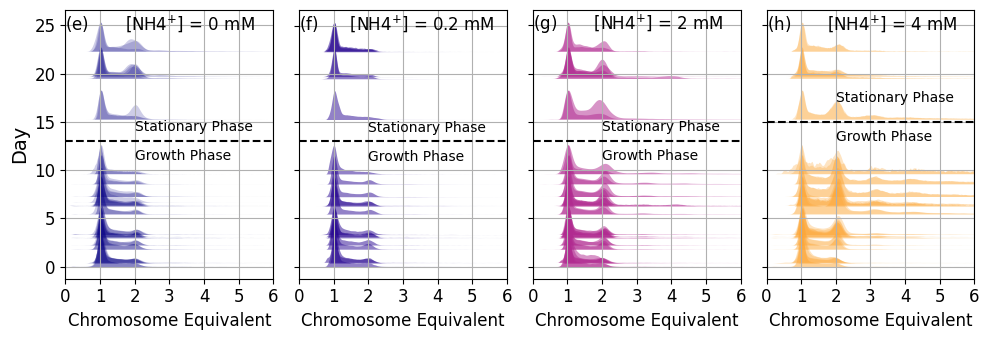

In [13]:
%matplotlib inline

fig, axs = plt.subplots(figsize = (10,3.5), ncols=4, nrows=1)
cmap=plt.get_cmap('plasma')

ax = axs[0]
for i in range(len(ridge_line_6_day)):
  y_base = ridge_line_6_day[i]
  gd = ridge_line_6[i]
  ax.fill_between(X_range_6, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0),
                 linewidth=0, alpha=0.2)

for i in range(len(ridge_line_7_day)):
  y_base = ridge_line_7_day[i]
  gd = ridge_line_7[i]
  ax.fill_between(X_range_7, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0),
                 linewidth=0, alpha=0.2)

for i in range(len(ridge_line_8_day)):
  y_base = ridge_line_8_day[i]
  gd = ridge_line_7[i]
  ax.fill_between(X_range_8, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0),
                 linewidth=0, alpha=0.2)

ax.plot([0,6],[13,13],'k--')
ax.text(2,14,'Stationary Phase')
ax.text(2,11,'Growth Phase')

ax.tick_params(labelsize=12)
ax.set_xlim(0,6)
ax.set_xticks([0,1,2,3,4,5,6])
ax.set_title('(e)       [NH4$^{+}$] = 0 mM', loc='Left')
ax.set_xlabel('Chromosome Equivalent', fontsize=12)
ax.set_ylabel('Day', fontsize=14)

ax = axs[1]

for i in range(len(ridge_line_5_day)):
  y_base = ridge_line_5_day[i]
  gd = ridge_line_5[i]
  ax.fill_between(X_range_5, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(0.2/5),
                 linewidth=0, alpha=0.5)

ax.plot([0,6],[13,13],'k--')
ax.text(2,14,'Stationary Phase')
ax.text(2,11,'Growth Phase')

ax.tick_params(labelsize=12)
ax.set_xlim(0,6)
ax.set_xticks([0,1,2,3,4,5,6])
ax.set_title('(f)      [NH4$^{+}$] = 0.2 mM', loc='Left')
ax.set_xlabel('Chromosome Equivalent', fontsize=12)
ax.set_yticklabels([])
#ax.set_ylabel('Day', fontsize=14)

ax = axs[2]

for i in range(len(ridge_line_1_day)):
  y_base = ridge_line_1_day[i]
  gd = ridge_line_1[i]
  ax.fill_between(X_range_1, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(2.0/5),
                 linewidth=0, alpha=0.5)

for i in range(len(ridge_line_4_day)):
  y_base = ridge_line_4_day[i]
  gd = ridge_line_4[i]
  ax.fill_between(X_range_4, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(2.0/5),
                 linewidth=0, alpha=0.5)

ax.plot([0,6],[13,13],'k--')
ax.text(2,14,'Stationary Phase')
ax.text(2,11,'Growth Phase')

ax.tick_params(labelsize=12)
ax.set_xlim(0,6)
ax.set_xticks([0,1,2,3,4,5,6])
ax.set_title('(g)       [NH4$^{+}$] = 2 mM', loc='Left')
ax.set_xlabel('Chromosome Equivalent', fontsize=12)
ax.set_yticklabels([])
#ax.set_ylabel('Day', fontsize=14)

ax = axs[3]

for i in range(len(ridge_line_2_day)):
  y_base = ridge_line_2_day[i]
  gd = ridge_line_2[i]
  ax.fill_between(X_range_2, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(4.0/5),
                 linewidth=0, alpha=0.3)

for i in range(len(ridge_line_3_day)):
  y_base = ridge_line_3_day[i]
  gd = ridge_line_3[i]
  ax.fill_between(X_range_3, 3*gd+y_base, np.zeros(len(gd))+y_base,
                 color=cmap(4.0/5),
                 linewidth=0, alpha=0.3)

ax.plot([0,6],[15,15],'k--')
ax.text(2,17,'Stationary Phase')
ax.text(2,13,'Growth Phase')
ax.tick_params(labelsize=12)
ax.set_xlim(0,6)
ax.set_xticks([0,1,2,3,4,5,6])
ax.set_title('(h)       [NH4$^{+}$] = 4 mM', loc='Left')
ax.set_xlabel('Chromosome Equivalent', fontsize=12)
ax.set_yticklabels([])
#ax.set_ylabel('Day', fontsize=14)

for ax in axs:
  ax.grid('on')
fig.tight_layout()

fig.savefig('/content/ridge_line_20230814.pdf')
fig.show()

In [14]:
ridge_line_all = [ridge_line_2, ridge_line_3, ridge_line_1, ridge_line_4,
                  ridge_line_5, ridge_line_6, ridge_line_7, ridge_line_8]

X_range_all = [X_range_2, X_range_3, X_range_1, X_range_4,
               X_range_5, X_range_6, X_range_7, X_range_8]

ridge_line_positive = np.mean(np.r_[ridge_line_6[(ridge_line_6_day>=2) & (ridge_line_6_day<=6)],
                                    ridge_line_7[(ridge_line_7_day>=2) & (ridge_line_7_day<=6)],
                                    ridge_line_8[(ridge_line_8_day>=2) & (ridge_line_8_day<=6)]], axis=0)

#ridge_line_positive = ridge_line_positive/np.max(ridge_line_positive[X_range_6<1.5])
#ridge_line_positive = ridge_line_positive/sum(ridge_line_positive[(X_range_6>=0) & (X_range_6<1.7)])
ridge_line_positive = ridge_line_positive/ridge_line_positive[X_range_6==1]

fractions_G1 = []
for i in range(len(ridge_line_all)):
  rl = ridge_line_all[i]
  X_range = X_range_all[i]

  #rl = (rl.T/rl[:, X_range<1.5].max(axis=1)).T

  rl = rl/(rl[:,X_range==1]/ridge_line_positive[X_range_6==1])

  #rl = (rl.T/np.sum(rl[:,(X_range>=0) & (X_range<1.7)], axis=1)).T

  #if len(rl[0]) == len(ridge_line_positive):
  #  differences_array = rl - ridge_line_positive
  #else:
  #  differences_array = np.c_[(rl[:, 0:len(ridge_line_positive)] - ridge_line_positive), rl[:, len(ridge_line_positive)::]]

  #rl_normalized = rl.T/np.sum(rl, axis=1)
  #rl_G1 = rl_normalized[X_range<=1.7].sum(axis=0)

  #fractions_G1.append(1 - differences_array[:,X_range>0].sum(axis=1)/rl.sum(axis=1))

  fractions_G1.append(ridge_line_positive.sum()/rl.sum(axis=1))

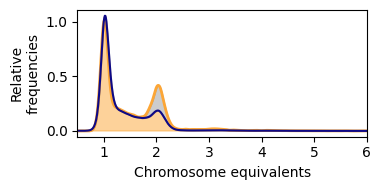

In [15]:
rl1 = ridge_line_3[4]
rl2 = ridge_line_positive

#rl1 = rl1/np.sum(rl1)
#rl2 = rl2/np.sum(rl2)

rl1 = rl1/(rl1[X_range_3==1]/rl2[X_range_6==1])

#rl1 = rl1/sum(rl1[(X_range_3>=0) & (X_range_3<1.7)])
#rl2 = rl2/sum(rl2[(X_range_6>=0) & (X_range_6<1.7)])

fig, axs = plt.subplots(figsize=(4,2))
ax = axs
ax.plot(X_range_3, rl1, '-', color = cmap(4.0/5), linewidth=2)
ax.plot(X_range_6, rl2, '-', color = cmap(0))
#ax.plot([1.7,1.7], [-0.001, 0.040], 'k--', alpha=0.5)

#ax.fill_between(X_range_3[(X_range_3>1.7) & (X_range_3<6)], rl1[(X_range_3>1.7) & (X_range_3<6)],
#                rl2[(X_range_6>1.7) & (X_range_6<6)], color = 'k', alpha=0.1)

#ax.fill_between(X_range_6[X_range_6>1.7], rl2[X_range_6>1.7], color=cmap(4.0/5), alpha=0.5)
#ax.fill_between(X_range_3[X_range_3<1.7], rl1[X_range_3<1.7], color=cmap(4.0/5), alpha=0.5)

ax.fill_between(X_range_6, rl2, color=cmap(4.0/5), alpha=0.5)
ax.fill_between(X_range_3[X_range_3<6], rl1[X_range_3<6], rl2[X_range_6<6], color = 'k', alpha=0.2)

ax.set_xlim(0.5,6)

ax.set_xlabel('Chromosome equivalents')
ax.set_ylabel('Relative\nfrequencies')
fig.tight_layout()

fig.savefig('/content/histogram_fraction_plot_early.pdf')
fig.show()

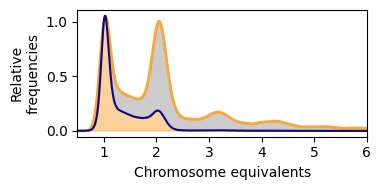

In [16]:
rl1 = ridge_line_3[8]
rl2 = ridge_line_positive

#rl1 = rl1/np.sum(rl1)
#rl2 = rl2/np.sum(rl2)

rl1 = rl1/(rl1[X_range_3==1]/rl2[X_range_6==1])

#rl1 = rl1/sum(rl1[(X_range_3>=0) & (X_range_3<1.7)])
#rl2 = rl2/sum(rl2[(X_range_6>=0) & (X_range_6<1.7)])

fig, axs = plt.subplots(figsize=(4,2))
ax = axs
ax.plot(X_range_3, rl1, '-', color = cmap(4.0/5), linewidth=2)
ax.plot(X_range_6, rl2, '-', color = cmap(0))

#ax.plot([1.7,1.7], [-0.001, 0.040], 'k--', alpha=0.5)

#ax.fill_between(X_range_3[(X_range_3>1.7) & (X_range_3<6)], rl1[(X_range_3>1.7) & (X_range_3<6)],
#                rl2[(X_range_6>1.7) & (X_range_6<6)], color = 'k', alpha=0.1)

#ax.fill_between(X_range_6[X_range_6>1.7], rl2[X_range_6>1.7], color=cmap(4.0/5), alpha=0.5)
#ax.fill_between(X_range_3[X_range_3<1.7], rl1[X_range_3<1.7], color=cmap(4.0/5), alpha=0.5)

ax.fill_between(X_range_6, rl2, color=cmap(4.0/5), alpha=0.5)
ax.fill_between(X_range_3[X_range_3<6], rl1[X_range_3<6], rl2[X_range_6<6], color = 'k', alpha=0.2)

ax.set_xlim(0.5,6)

ax.set_xlabel('Chromosome equivalents')
ax.set_ylabel('Relative\nfrequencies')
fig.tight_layout()

fig.savefig('/content/histogram_fraction_plot.pdf')
fig.show()

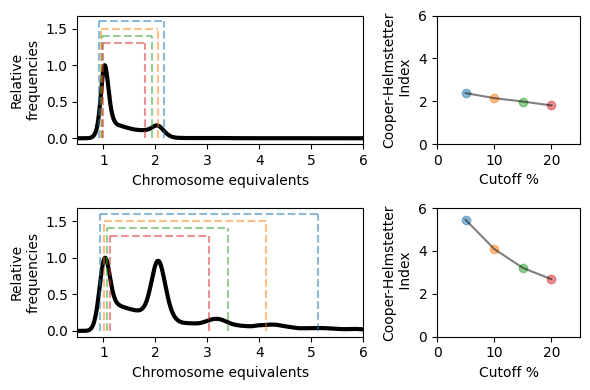

In [17]:
rl1 = ridge_line_3[8]
rl2 = ridge_line_positive

rl1 = rl1/np.sum(rl1)
rl2 = rl2/np.sum(rl2)

fig, axs = plt.subplots(ncols = 2, nrows = 2, figsize=(6,4), gridspec_kw={'width_ratios': [2,1]})

axs[1,0].plot(X_range_3, rl1/np.max(rl1), '-', color = 'k', linewidth=3)
axs[0,0].plot(X_range_6, rl2/np.max(rl2), '-', color = 'k', linewidth=3)

rl_list = [rl1, rl2]
X_range_list = [X_range_3, X_range_6]
cutoff_list = np.array([0.05, 0.1, 0.15, 0.2])
for i in range(2):
  hist_ax = axs[1-i,0]
  target_ax = axs[1-i, 1]
  rl = rl_list[i]
  rl_cumsum = np.cumsum(rl)
  X_range = X_range_list[i]
  CHI_list = []
  for j in range(len(cutoff_list)):
    cutoff = cutoff_list[j]
    upper_margin = X_range[np.argmin(
                                  np.abs(
                                      rl_cumsum-(1-cutoff))
                            )]
    lower_margin = X_range[np.argmin(
                                  np.abs(
                                      rl_cumsum-cutoff)
                            )]
    CHI_list.append(upper_margin/lower_margin)
    hist_ax.plot([lower_margin, lower_margin], [0,1.6-0.1*j], '--', color=plt.cm.tab10(j), alpha=0.5)
    hist_ax.plot([upper_margin, upper_margin], [0,1.6-0.1*j], '--', color=plt.cm.tab10(j), alpha=0.5)
    hist_ax.plot([lower_margin, upper_margin], [1.6-0.1*j,1.6-0.1*j],'--', color=plt.cm.tab10(j), alpha=0.5)
    target_ax.plot(100*cutoff, upper_margin/lower_margin, 'o', color=plt.cm.tab10(j), alpha=0.5)
  target_ax.plot(100*cutoff_list, CHI_list, 'k-', alpha=0.5)

for ax in axs[:,0]:
  ax.set_xlim(0.5,6)
  ax.set_xlabel('Chromosome equivalents')
  ax.set_ylabel('Relative\nfrequencies')

for ax in axs[:,1]:
  ax.set_xlim(0,25)
  ax.set_ylim(0,6)
  ax.set_xlabel('Cutoff %')
  ax.set_ylabel('Cooper-Helmstetter\n Index')

fig.tight_layout()

fig.savefig('/content/histogram_cooper_helmstetter_index.pdf')
fig.show()

In [18]:
def get_idr(day, cell_count, sw = 3):
  time = np.array(day)
  log2cd = np.log2(cell_count)

  idr_list = []
  time_list = []

  for i in range(sw, len(log2cd)+1):
    time_array = time[i-sw:i]
    if np.max(time_array)>np.min(time_array):
      LR = linregress(time_array,log2cd[i-sw:i])
      for idr in [LR.slope, LR.slope+LR.stderr, LR.slope-LR.stderr]:
        idr_list.append([idr, idr, idr, idr])
        time_list.append([np.max(time_array), np.median(time_array), np.mean(time_array), np.min(time_array)])

  time_list = np.array(time_list).flatten()
  idr_list = np.array(idr_list).flatten()

  sel_bool = (time_list<30)

  #interpolation fit
  unique_time = np.unique(np.round(time_list,0))
  idr_median = []
  for ut in unique_time:
    idr_group = idr_list[abs(time_list-ut)<=0.5]
    median_idr = np.median(idr_group)
    idr_median.append(median_idr)

  t_fit = np.arange(np.min(time_list[sel_bool]), np.max(time_list[sel_bool]), 0.1)
  y_interp = np.interp(t_fit, unique_time, idr_median)

  idr_ = np.array([np.mean(y_interp[abs(t_fit-y_base)<1]) for y_base in time])

  return idr_

In [19]:
day_all = [ridge_line_2_day, ridge_line_3_day, ridge_line_1_day, ridge_line_4_day,
           ridge_line_5_day, ridge_line_6_day, ridge_line_7_day, ridge_line_8_day]
cell_count_all = [cell_count_2, cell_count_3, cell_count_1, cell_count_4,
                  cell_count_5, cell_count_6, cell_count_7, cell_count_8]

In [20]:
idr_all_samples = [get_idr(day=day_all[i], cell_count=cell_count_all[i], sw = 4) for i in range(len(day_all))]

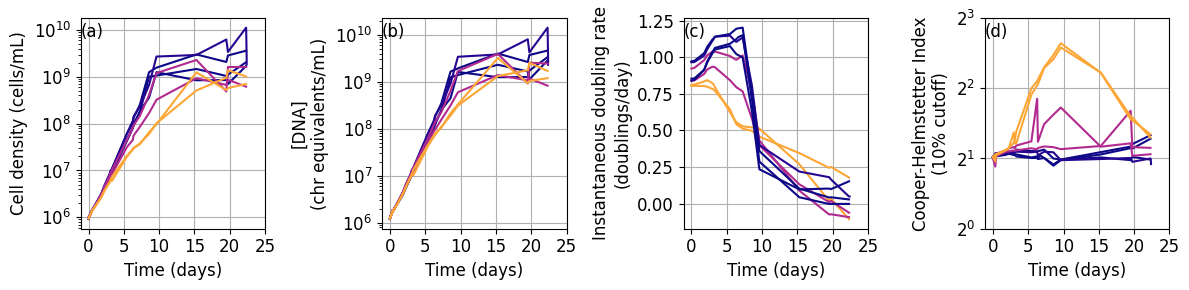

In [21]:
%matplotlib inline

fig, axs = plt.subplots(figsize = (12,3), ncols=4, nrows=1)
cmap=plt.get_cmap('plasma')
ax = axs[0]

ax.plot(ridge_line_6_day, cell_count_6, '-', color = cmap(0))
ax.plot(ridge_line_7_day, cell_count_7, '-', color = cmap(0))
ax.plot(ridge_line_8_day, cell_count_8, '-', color = cmap(0))

ax.plot(ridge_line_5_day, cell_count_5, '-', color = cmap(0.2/5))

ax.plot(ridge_line_1_day, cell_count_1, '-', color = cmap(2.0/5))
ax.plot(ridge_line_4_day, cell_count_4, '-', color = cmap(2.0/5))

ax.plot(ridge_line_2_day, cell_count_2, '-', color = cmap(4.0/5))
ax.plot(ridge_line_3_day, cell_count_3, '-', color = cmap(4.0/5))

ax.set_yscale('log', base=10)

ax.set_ylabel('Cell density (cells/mL)', fontsize=12)
ax.set_title('(a)', loc='Left')

ax = axs[1]

ax.plot(ridge_line_6_day, cell_count_6*chromosome_per_cell_6, '-', color = cmap(0))
ax.plot(ridge_line_7_day, cell_count_7*chromosome_per_cell_7, '-', color = cmap(0))
ax.plot(ridge_line_8_day, cell_count_8*chromosome_per_cell_8, '-', color = cmap(0))

ax.plot(ridge_line_5_day, cell_count_5*chromosome_per_cell_5, '-', color = cmap(0.2/5))

ax.plot(ridge_line_1_day, cell_count_1*chromosome_per_cell_1, '-', color = cmap(2.0/5))
ax.plot(ridge_line_4_day, cell_count_4*chromosome_per_cell_4, '-', color = cmap(2.0/5))

ax.plot(ridge_line_2_day, cell_count_2*chromosome_per_cell_2, '-', color = cmap(4.0/5))
ax.plot(ridge_line_3_day, cell_count_3*chromosome_per_cell_3, '-', color = cmap(4.0/5))
ax.set_yscale('log', base=10)

ax.set_ylabel('[DNA]\n(chr equivalents/mL)', fontsize=12)

ax.set_title('(b)', loc='Left')

ax = axs[2]
for i in range(len(day_all)):
  da = day_all[i]
  idr = idr_all_samples[i]
  if i in [0,1]:
    color = cmap(4.0/5)
  elif i in [2,3]:
    color = cmap(2.0/5)
  elif i==4:
    color = cmap(0.2/5)
  else:
    color = cmap(0)
  ax.plot(da, idr, '-', color = color)
ax.set_ylabel('Instantaneous doubling rate\n(doublings/day)', fontsize=12)
ax.set_title('(c)', loc = 'Left')

ax = axs[3]
ax.plot(ridge_line_6_day, chi_6, '-', color = cmap(0))
ax.plot(ridge_line_7_day, chi_7, '-', color = cmap(0))
ax.plot(ridge_line_8_day, chi_8, '-', color = cmap(0))

ax.plot(ridge_line_5_day, chi_5, '-', color = cmap(0.2/5))

ax.plot(ridge_line_1_day, chi_1, '-', color = cmap(2.0/5))
ax.plot(ridge_line_4_day, chi_4, '-', color = cmap(2.0/5))

ax.plot(ridge_line_2_day, chi_2, '-', color = cmap(4.0/5))
ax.plot(ridge_line_3_day, chi_3, '-', color = cmap(4.0/5))
ax.set_ylim(1,8)
ax.set_yscale('log', base=2)

ax.set_ylabel('Cooper-Helmstetter Index\n(10% cutoff)', fontsize=12)
ax.set_title('(d)', loc = 'Left')


for ax in axs:
  ax.set_xticks([0,5,10,15,20,25])
  ax.tick_params(labelsize=12)
  ax.set_xlabel('Time (days)', fontsize=12)
  ax.grid('on')

fig.tight_layout()
fig.savefig('/content/curves_20230814_2.pdf')
fig.show()

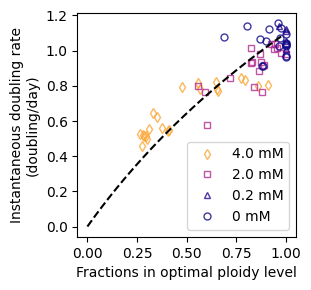

In [22]:
fig, axs = plt.subplots(figsize=(3.2,3.0))
ax = axs

concentrations = [4.0,4.0,2.0,2.0,0.2,0,0,0]
fractions_fit = np.arange(0, 1, 0.01)

all_fraction_plot = np.array([])
all_idr_plot = np.array([])

labeled_legends=[]
for i in range(len(idr_all_samples)):
  idr_sample = idr_all_samples[i]
  fG1 = fractions_G1[i]
  fG1[fG1>1] = 1
  day = day_all[i]

  NH4_conc = concentrations[i]

  shape = 'o'

  if NH4_conc==0:
    idr_plot = idr_sample[(day>=1) & (day<=6)]
    fraction_plot = fG1[(day>=1) & (day<=6)]
    shape = 'o'
  elif NH4_conc == 0.2:
    idr_plot = idr_sample[(day>=1) & (day<=5)]
    fraction_plot = fG1[(day>=1) & (day<=5)]
    shape = '^'
  elif NH4_conc==2:
    idr_plot = idr_sample[(day>=1) & (day<=9)]
    fraction_plot = fG1[(day>=1) & (day<=9)]
    shape = 's'
  else:
    idr_plot = idr_sample[(day>=1) & (day<=10)]
    fraction_plot = fG1[(day>=1) & (day<=10)]
    shape = 'd'

  #fraction_plot = fraction_plot-0.05
  if NH4_conc in labeled_legends:
    ax.plot(fraction_plot, idr_plot, shape, color = cmap(NH4_conc/5), mfc = 'none', markersize=5, alpha=0.8)
  else:
    ax.plot(fraction_plot, idr_plot, shape, color = cmap(NH4_conc/5), mfc = 'none', markersize=5, alpha=0.8, label = str(NH4_conc)+' mM')
    labeled_legends.append(NH4_conc)

  all_fraction_plot = np.r_[all_fraction_plot, fraction_plot]
  all_idr_plot = np.r_[all_idr_plot, idr_plot]

#dr_max = np.mean(all_idr_plot/np.log2(1+all_fraction_plot))
#dr_max = np.max(all_idr_plot)
dr_max = 1.1
ax.plot(fractions_fit, dr_max*np.log2(1+fractions_fit),'k--')

#ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_xlabel('Fractions in optimal ploidy level')
ax.set_ylabel('Instantaneous doubling rate\n(doubling/day)')

#ax.set_xticks([0, 0.1, 0.2,0.3, 0.4,0.5,0.6,0.7, 0.8,0.9, 1])
#ax.set_yticks([0, 0.1, 0.2,0.3, 0.4,0.5,0.6,0.7, 0.8,0.9, 1, 1.1, 1.2])

#ax.set_xticklabels([0,'','','','',0.5,'','','','',1])
#ax.set_yticklabels([0,'','','','',0.5,'','','','',1,'',''])
#ax.legend(bbox_to_anchor=(1,1))
ax.legend(loc=4)

fig.tight_layout()

fig.savefig('/content/viability_fractions.pdf')
fig.show()

In [23]:
dr_max

1.1

In [24]:
import matplotlib

In [25]:
cell_count_6

array([9.54400000e+05, 1.26724444e+06, 1.35422222e+06, 3.13960000e+06,
       4.72780000e+06, 8.33440000e+06, 9.79520000e+06, 1.09504000e+07,
       6.21152000e+07, 1.14874000e+08, 1.33330000e+08, 2.50126000e+08,
       1.25864000e+09, 1.57020000e+09, 3.00634000e+09, 2.07916000e+09,
       2.85956000e+09, 3.62056000e+09])

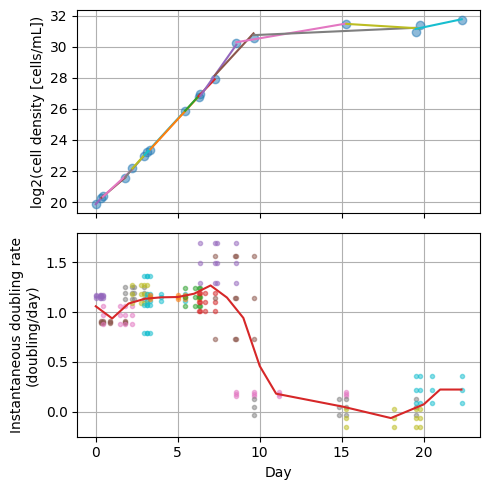

In [26]:
time = np.array(ridge_line_6_day)
log2cd = np.log2(cell_count_6)

fig, axs = plt.subplots(nrows = 2, figsize=(5,5))

colormap = matplotlib.colormaps['tab10']

axs[0].plot(time, log2cd, 'C0o', alpha=0.5)
sw = 3
idr_list = []
time_list = []

for i in range(sw, len(log2cd)+1):
  time_array = time[i-sw:i]
  if np.max(time_array)>np.min(time_array):
    LR = linregress(time_array,log2cd[i-sw:i])
    axs[0].plot(time_array, LR.slope*time_array+LR.intercept, '-', color = colormap(i%10+1))
    for idr in [LR.slope, LR.slope+LR.stderr, LR.slope-LR.stderr]:
      idr_list.append([idr, idr, idr, idr])
      time_list.append([np.max(time_array), np.median(time_array), np.mean(time_array), np.min(time_array)])
      axs[1].plot([np.max(time_array), np.median(time_array), np.mean(time_array), np.min(time_array)],[idr, idr, idr, idr],  '.',  alpha = 0.5, color = colormap(i%10+1))

time_list = np.array(time_list).flatten()
idr_list = np.array(idr_list).flatten()


sel_bool = (time_list<30)
#time_min = np.min(time_list[idr_list==np.max(idr_list)])
#sel_bool = (time_list>time_min)
(a_, b_, c_, d_), _ = curve_fit(sigmoid, time_list[sel_bool], idr_list[sel_bool], method = 'trf')

#interpolation fit
unique_time = np.unique(np.round(time_list,0))
idr_median = []
for ut in unique_time:
  idr_group = idr_list[abs(time_list-ut)<=0.5]
  median_idr = np.mean(idr_group)
  idr_median.append(median_idr)

#axs[1].plot(unique_time, idr_median, 'C3o', mfc = 'none')

t_fit = np.arange(np.min(time_list[sel_bool]), np.max(time_list[sel_bool]), 0.1)
y_fit = sigmoid(t_fit, a_, b_, c_, d_)

y_interp = np.interp(t_fit, unique_time, idr_median)

#axs[1].plot(t_fit, y_fit, 'C0-', linewidth=2)
axs[1].plot(t_fit, y_interp, 'C3-')
#axs[1].plot([d_, d_], [np.min(idr_median)-0.1, np.max(idr_median)+0.1], 'k--')

axs[0].set_xticklabels([])
axs[1].set_xlabel('Day')
axs[0].set_ylabel('log2(cell density [cells/mL])')
axs[1].set_ylabel('Instantaneous doubling rate\n(doubling/day)')

for ax in axs:
  ax.grid('on')
fig.tight_layout()

fig.savefig('/content/Growth_curve_fit_example.pdf')
fig.show()

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize = (6.6,4.5))

output_list = []
BCD_list = []
X_range = np.round(X_range_3,2)
days = ridge_line_3_day[ridge_line_3_day<5]
ridge_line_data = ridge_line_2[ridge_line_3_day<5]

a = np.linspace(0, 0.999, 1000)
n = np.log(2)*2**(1-a)

ax = axs[0]

predict_i_list = []
idr_list = []
for i in range(len(days)):
  y_base = days[i]
  gd = ridge_line_data[days == y_base].mean(axis=0)
  idr = np.mean(y_interp[abs(t_fit-y_base)<1])

  if idr<0:
    ax.fill_between(X_range, 10*gd+y_base, np.zeros(len(gd))+y_base,
                  color='k',
                  linewidth=0, alpha=0.2)
  else:
    predict_i_list.append(i)
    idr_list.append(idr)
    ax.fill_between(X_range, 10*gd+y_base, np.zeros(len(gd))+y_base,
                  color='k',
                  linewidth=0, alpha=0.2)

    (C,D,u,u0) = run_optimization(X_range, gd)
    #(C,D,u) = run_optimization(X_range, ridge_line)
    output_list.append([C,D,u,u0])
    #output_list.append([C,D,u])

    B = 1-C-D
    fractions=np.array([B, C, D])
    BCD_list.append(fractions)

    G_linspace, n_G_A = theoretical_DNA_distribution_CD(C=C, D=D)

    n_B = np.r_[n_G_A[0], np.zeros(len(n_G_A)-1)]
    n_C = np.r_[0, n_G_A[1:-1], 0]
    n_D = np.r_[np.zeros(len(n_G_A)-1), n_G_A[-1]]

    xi_list = np.arange(G_linspace[int(np.floor(len(G_linspace)/2))]-G_linspace[0],
                          G_linspace[int(np.floor(len(G_linspace)/2))]+G_linspace[1], 0.001)
    N_xi_B = np.array([np.sum(n_B*V_func(xi, u, u0, G_linspace))*0.001 for xi in xi_list])
    N_xi_C = np.array([np.sum(n_C*V_func(xi, u, u0, G_linspace))*0.001 for xi in xi_list])
    N_xi_D = np.array([np.sum(n_D*V_func(xi, u, u0, G_linspace))*0.001 for xi in xi_list])

    x_axis=xi_list

    y_axis0=N_xi_B/np.max(N_xi_B)
    y_axis1=N_xi_C/np.max(N_xi_B)
    y_axis2=N_xi_D/np.max(N_xi_B)

    ax.plot(x_axis, 10*y_axis0+y_base, lw=1, c='C0')
    ax.plot(x_axis, 10*y_axis1+y_base, lw=1, c='C1')
    ax.plot(x_axis, 10*y_axis2+y_base, lw=1, c='C3')

    ax.plot(x_axis, 10*(y_axis0+y_axis1+y_axis2)+y_base, 'k--', lw = 1)

#ax.set_title('No antibiotics\n[NH4+]=0', loc='Right')
ax.set_ylabel('Day', fontsize=14)
ax.set_xticks([1,2,3,4,5])
ax.set_xlabel('Chromosome Equivalent', fontsize=14)

BCD_list = np.array(BCD_list)
BCD_cumsum = np.cumsum(BCD_list, axis=1)
ax=axs[1]
ax.fill_betweenx(days[predict_i_list], 100*BCD_cumsum[:,0], color='C0')
ax.fill_betweenx(days[predict_i_list], 100*BCD_cumsum[:,1], 100*BCD_cumsum[:,0], color='C1')
ax.fill_betweenx(days[predict_i_list], 100*BCD_cumsum[:,2], 100*BCD_cumsum[:,1], color='C3')

ax.set_xlabel('Fraction (%)', fontsize=14)

for ax in axs:
  #ax.set_ylim(0,12.5)
  ax.tick_params(labelsize=12)

axs[1].set_yticks([])

output_list = np.array(output_list)

fig.tight_layout()

fig.savefig('Flask_3_ploidy_level_fit_day1-5.pdf')
fig.show()

/tmp/ipython-input-195909385.py:205: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res0 = minimize(#KS_test_objective,


[0.45635895 0.18453842 0.05469658 0.01093932]
Optimization terminated successfully.
         Current function value: 4.995813
         Iterations: 91
         Function evaluations: 210
[0.41167724 0.16611149 0.06762942 0.01090968]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.2811e-01                                    1.91e+00    
       1              2         1.8830e-01      3.98e-02       7.97e-02       3.78e-02    
       2              3         1.8018e-01      8.12e-03       4.82e-02       2.44e-02    
       3              4         1.7954e-01      6.44e-04       1.57e-02       5.18e-03    
       4              5         1.7953e-01      1.20e-05       2.37e-03       2.61e-04    
       5              6         1.7953e-01      3.54e-08       1.17e-04       1.81e-05    
       6              7         1.7953e-01      1.24e-10       5.43e-06       2.07e-06    
       7              8         1.7953e-0

In [ ]:
dt_select=(24/np.array(idr_list))
np.r_[[dt_select], (BCD_list.T*dt_select)].T

In [ ]:
HTCC1062_tau_B_C_D_0_ammonia_20230814 = np.array([
    #Flask 6
    [23.09151613,  9.09352788, 10.04056038,  3.95742787],
    [22.13260366,  8.73262494, 10.38778838,  3.01219034],
    [21.32702774,  9.62107694,  8.73848683,  2.96746397],
    [21.26778874, 10.1187234 ,  8.27798168,  2.87108366],
    [21.11740822, 10.02238116,  8.67389158,  2.42113547],

    #Flask 7
    [25.80918304,  9.30079956, 12.13693183,  4.37145165],
    [24.34058047,  9.37538353, 10.862078  ,  4.10311894],
    [23.05216164,  7.4282205 , 12.1680517 ,  3.45588944],
    [22.94224756, 11.33612854,  8.84212799,  2.76399103],
    [22.66469669, 11.09704953,  8.82544941,  2.74219774],

    #Flask 8
    [25.70622313,  9.56329716, 11.08428721,  5.05863877],
    [24.12826182,  8.83354176, 11.29678394,  3.99793612],
    [22.74255984,  7.77979221, 11.07479231,  3.88797531],
    [22.63136896,  9.77858893,  9.21527716,  3.63750288],
    [22.37478717,  7.52137168, 11.19726078,  3.65615471]
                                                  ])

HTCC1062_tau_B_C_D_0_2mM_ammonia_20230814 = np.array([
    #Flask 5
    [25.70622313,  9.56329716, 11.08428721,  5.05863877],
    [24.12826182,  8.83354176, 11.29678394,  3.99793612],
    [22.74255984,  7.77979221, 11.07479231,  3.88797531],
    [22.63136896,  9.77858893,  9.21527716,  3.63750288],
    [22.37478717,  7.52137168, 11.19726078,  3.65615471]])

HTCC1062_tau_B_C_D_2mM_ammonia_20230814 = np.array([
    #Flask 1
    [23.42266994,  8.09672882, 11.20868738,  4.11725374],
    [23.00165755,  9.23646806,  9.92724809,  3.8379414 ],
    [23.00180277,  9.18436566,  9.6487396 ,  4.16869752],
    [23.0507732 ,  8.32327177, 11.04744211,  3.68005933],
    #Flask 4
    [26.86499586,  8.37565127, 12.81769302,  5.67165158],
    [26.00585209,  8.4525485 , 11.37901448,  6.17428911],
    [25.67404348,  8.97465247, 10.3960418 ,  6.30334921],
    [25.71636619,  8.62354372, 12.40487005,  4.68795242],
    [25.91196594,  8.55744457, 11.23598501,  6.11853636],
    ])

HTCC1062_tau_B_C_D_4mM_ammonia_20230814 = np.array([
    #Flask 2
    [28.82751596,  7.81952734, 13.29557881,  7.71240981],
    [28.71979585,  7.82703589, 11.2795815 ,  9.61317847],
    [29.61754358,  7.16006508, 11.74446428, 10.71301422],
    [29.86536014,  7.20494017, 12.43205539, 10.22836459],
    [30.70197922,  7.62956562, 11.77323978, 11.29917382],
    #Flask 3
    [29.95884657,  8.93979161, 12.3073421 ,  8.71171286],
    [30.17736688,  8.32550665, 12.41595425,  9.43590598],
    [30.77220454,  7.78629818, 11.58307033, 11.40283603],
    [30.88794134,  7.94076175, 12.16021211, 10.78696748],
    [31.28196086,  8.00297862, 11.23748021, 12.04150203]
                                                     ])

In [ ]:
fig, axs = plt.subplots(figsize=(3,2))

cmap2=plt.get_cmap('plasma')

data_list = [HTCC1062_tau_B_C_D_0_ammonia_20230814,
             HTCC1062_tau_B_C_D_2mM_ammonia_20230814,
             HTCC1062_tau_B_C_D_4mM_ammonia_20230814]

color_list = [cmap2(0), cmap2(2.0/5), cmap2(4.0/5)]
for i in range(3):
  for j in range(4):
    x_loc = j*4+i
    axs.plot(x_loc+np.random.randn(len(data_list[i][:,j]))*0.1,
              data_list[i][:,j], '.', markersize=3, color = color_list[i])
    violin_parts = axs.violinplot(data_list[i][:,j], positions=[x_loc],
                                  showmeans=True, showextrema=False, vert=True,
                                  widths=1)
    for partname in ('bodies', 'cmeans'):
      pc = violin_parts[partname]
      if partname == 'bodies':
        for p in pc:
          p.set_facecolor(color_list[i])
          p.set_alpha(0.5)
      else:
        pc.set_edgecolor('k')

axs.set_xticks([1,5,9,13])
axs.set_xticklabels(['τ', 'B', 'C', 'D'])

colors = ['k', 'C0', 'C1', 'C3']
for xtick, color in zip(axs.get_xticklabels(), colors):
    xtick.set_color(color)

axs.set_ylabel('Hours')
axs.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig('BCD_violin_HTCC1062_ammonia_20230814.pdf')
fig.show()

In [ ]:
#import matplotlib.pyplot as plt
#import numpy as np
from scipy.stats import kruskal, mannwhitneyu

# Option 1: Add p-values as text annotations
def add_pvalue_annotation(ax, data_groups, positions, test='kruskal', period_idx=0):
    """Add p-value annotations above violin plots"""
    if test == 'kruskal':
        # Kruskal-Wallis test for multiple groups
        stat, p_value = kruskal(*data_groups)
        ax.text(np.mean(positions), ax.get_ylim()[1] * 0.95,
                f'Kruskal-Wallis p={p_value:.3f}',
                ha='center', va='top', fontsize=8)
    elif test == 'pairwise':
        # Show two key comparisons: 0mM vs 2mM and 0mM vs 4mM
        comparisons = [(0, 1), (0, 2)]  # 0mM vs 2mM and 0mM vs 4mM

        for comp_idx, (i, j) in enumerate(comparisons):
            stat, p_value = mannwhitneyu(data_groups[i], data_groups[j])

            # Calculate max_y based only on the two groups being compared
            max_y = max(np.max(data_groups[i]), np.max(data_groups[j]))
            y_offset = max_y * 0.08  # Spacing between brackets

            # Adjust spacing: give more space for 0mM vs 4mM brackets on B, C, D periods
            if j == 2 and period_idx > 0:  # 0mM vs 4mM comparison for B, C, D periods
                y_pos = max_y + y_offset * (comp_idx + 4)  # Extra spacing
            else:
                y_pos = max_y + y_offset * (comp_idx + 1)  # Normal spacing

            x1, x2 = positions[i], positions[j]

            # Draw cleaner bracket
            bracket_height = y_offset * 0.15
            ax.plot([x1, x1, x2, x2],
                   [y_pos, y_pos + bracket_height, y_pos + bracket_height, y_pos],
                   'k-', linewidth=1)

            # Add p-value text
            sig_text = get_significance_stars(p_value)
            ax.text((x1+x2)/2, y_pos + bracket_height + y_offset*0.1, sig_text,
                   ha='center', va='bottom', fontsize=9, weight='bold')

def get_significance_stars(p_value):
    """Convert p-value to significance stars"""
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'  # Simplified - no p-value shown

# Your original figure code with statistical additions
fig, axs = plt.subplots(figsize=(4, 2.5))  # Taller figure for annotations

data_list = [HTCC1062_tau_B_C_D_0_ammonia_20230814,
             HTCC1062_tau_B_C_D_2mM_ammonia_20230814,
             HTCC1062_tau_B_C_D_4mM_ammonia_20230814]

color_list = [cmap2(0), cmap2(2.0/5), cmap2(4.0/5)]

# Create violin plots as before
for i in range(3):
    for j in range(4):
        x_loc = j*4+i
        axs.plot(x_loc+np.random.randn(len(data_list[i][:,j]))*0.1,
                  data_list[i][:,j], '.', markersize=3, color = color_list[i])
        violin_parts = axs.violinplot(data_list[i][:,j], positions=[x_loc],
                                      showmeans=True, showextrema=False, vert=True,
                                      widths=0.8)  # Slightly narrower violins
        for partname in ('bodies', 'cmeans'):
            pc = violin_parts[partname]
            if partname == 'bodies':
                for p in pc:
                    p.set_facecolor(color_list[i])
                    p.set_alpha(0.6)  # Slightly more opaque
            else:
                pc.set_edgecolor('k')
                pc.set_linewidth(1.5)  # Thicker mean lines

# Add statistical comparisons for each period (τ, B, C, D)
period_names = ['τ', 'B', 'C', 'D']
for period_idx, j in enumerate(range(4)):
    # Extract data for this period across all ammonium concentrations
    period_data = [data_list[i][:,j] for i in range(3)]
    positions = [j*4+i for i in range(3)]

    # Add pairwise comparisons, passing period index for spacing adjustment
    add_pvalue_annotation(axs, period_data, positions, test='pairwise', period_idx=period_idx)

# Adjust y-axis to accommodate annotations
axs.set_ylim(bottom=0, top=axs.get_ylim()[1] * 1.2)

axs.set_xticks([1,5,9,13])
axs.set_xticklabels(['τ', 'B', 'C', 'D'])

colors = ['k', 'C0', 'C1', 'C3']
for xtick, color in zip(axs.get_xticklabels(), colors):
    xtick.set_color(color)
    #xtick.set_fontweight('bold')  # Bold period labels

#axs.set_ylabel('Hours', fontweight='bold')
axs.set_ylabel('Hours')

# Clean up the plot
#axs.spines['top'].set_visible(False)
#axs.spines['right'].set_visible(False)

# Add legend for ammonium concentrations
legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                             markerfacecolor=color_list[i], markersize=8,
                             label=f'{[0, 2, 4][i]} mM NH₄⁺')
                  for i in range(3)]
axs.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig('BCD_violin_HTCC1062_ammonia_20230814_Mann-Whitney-U.pdf')
fig.show()

# Option 2: Create a summary statistics table
def create_stats_table(data_list, period_names):
    """Create a summary table with statistics"""
    import pandas as pd

    results = []
    for j, period in enumerate(period_names):
        for i, conc in enumerate([0, 2, 4]):
            data = data_list[i][:,j]
            results.append({
                'Period': period,
                'NH4_mM': conc,
                'Mean': np.mean(data),
                'Std': np.std(data),
                'Median': np.median(data),
                'N': len(data)
            })

    df = pd.DataFrame(results)
    print("Summary Statistics:")
    print(df.pivot(index='Period', columns='NH4_mM', values=['Mean', 'Std', 'Median']))

    # Statistical tests
    print("\nStatistical Tests (Kruskal-Wallis):")
    for j, period in enumerate(period_names):
        period_data = [data_list[i][:,j] for i in range(3)]
        stat, p_value = kruskal(*period_data)
        print(f"{period}: H={stat:.3f}, p={p_value:.4f}")

# Option 3: Heatmap of p-values for pairwise comparisons
def create_pvalue_heatmap(data_list, period_names):
    """Create heatmap showing pairwise p-values"""
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))

    for j, period in enumerate(period_names):
        # Calculate pairwise p-values
        p_matrix = np.ones((3, 3))
        for i in range(3):
            for k in range(3):
                if i != k:
                    stat, p_val = mannwhitneyu(data_list[i][:,j], data_list[k][:,j])
                    p_matrix[i, k] = p_val

        # Create heatmap
        im = axes[j].imshow(p_matrix, cmap='RdYlBu_r', vmin=0, vmax=0.05)
        axes[j].set_title(f'{period}')
        axes[j].set_xticks([0, 1, 2])
        axes[j].set_yticks([0, 1, 2])
        axes[j].set_xticklabels(['0 mM', '2 mM', '4 mM'])
        axes[j].set_yticklabels(['0 mM', '2 mM', '4 mM'])

        # Add p-values as text
        for i in range(3):
            for k in range(3):
                text = axes[j].text(k, i, f'{p_matrix[i, k]:.6f}',
                                   ha="center", va="center", color="black", fontsize=8)

    plt.tight_layout()
    plt.show()

# Call the functions to generate additional analyses
create_stats_table(data_list, period_names)
create_pvalue_heatmap(data_list, period_names)